# ANN 2 - Regression - Combined Cycle Power Plants

## Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
tf.__version__

'2.20.0'

In [3]:
start_time = time.time()

## Part 1 - Data Preprocessing

### Importing the dataset

In [4]:
dataset = pd.read_excel('../Data/Folds5x2_pp.xlsx')
dataset.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


<Axes: >

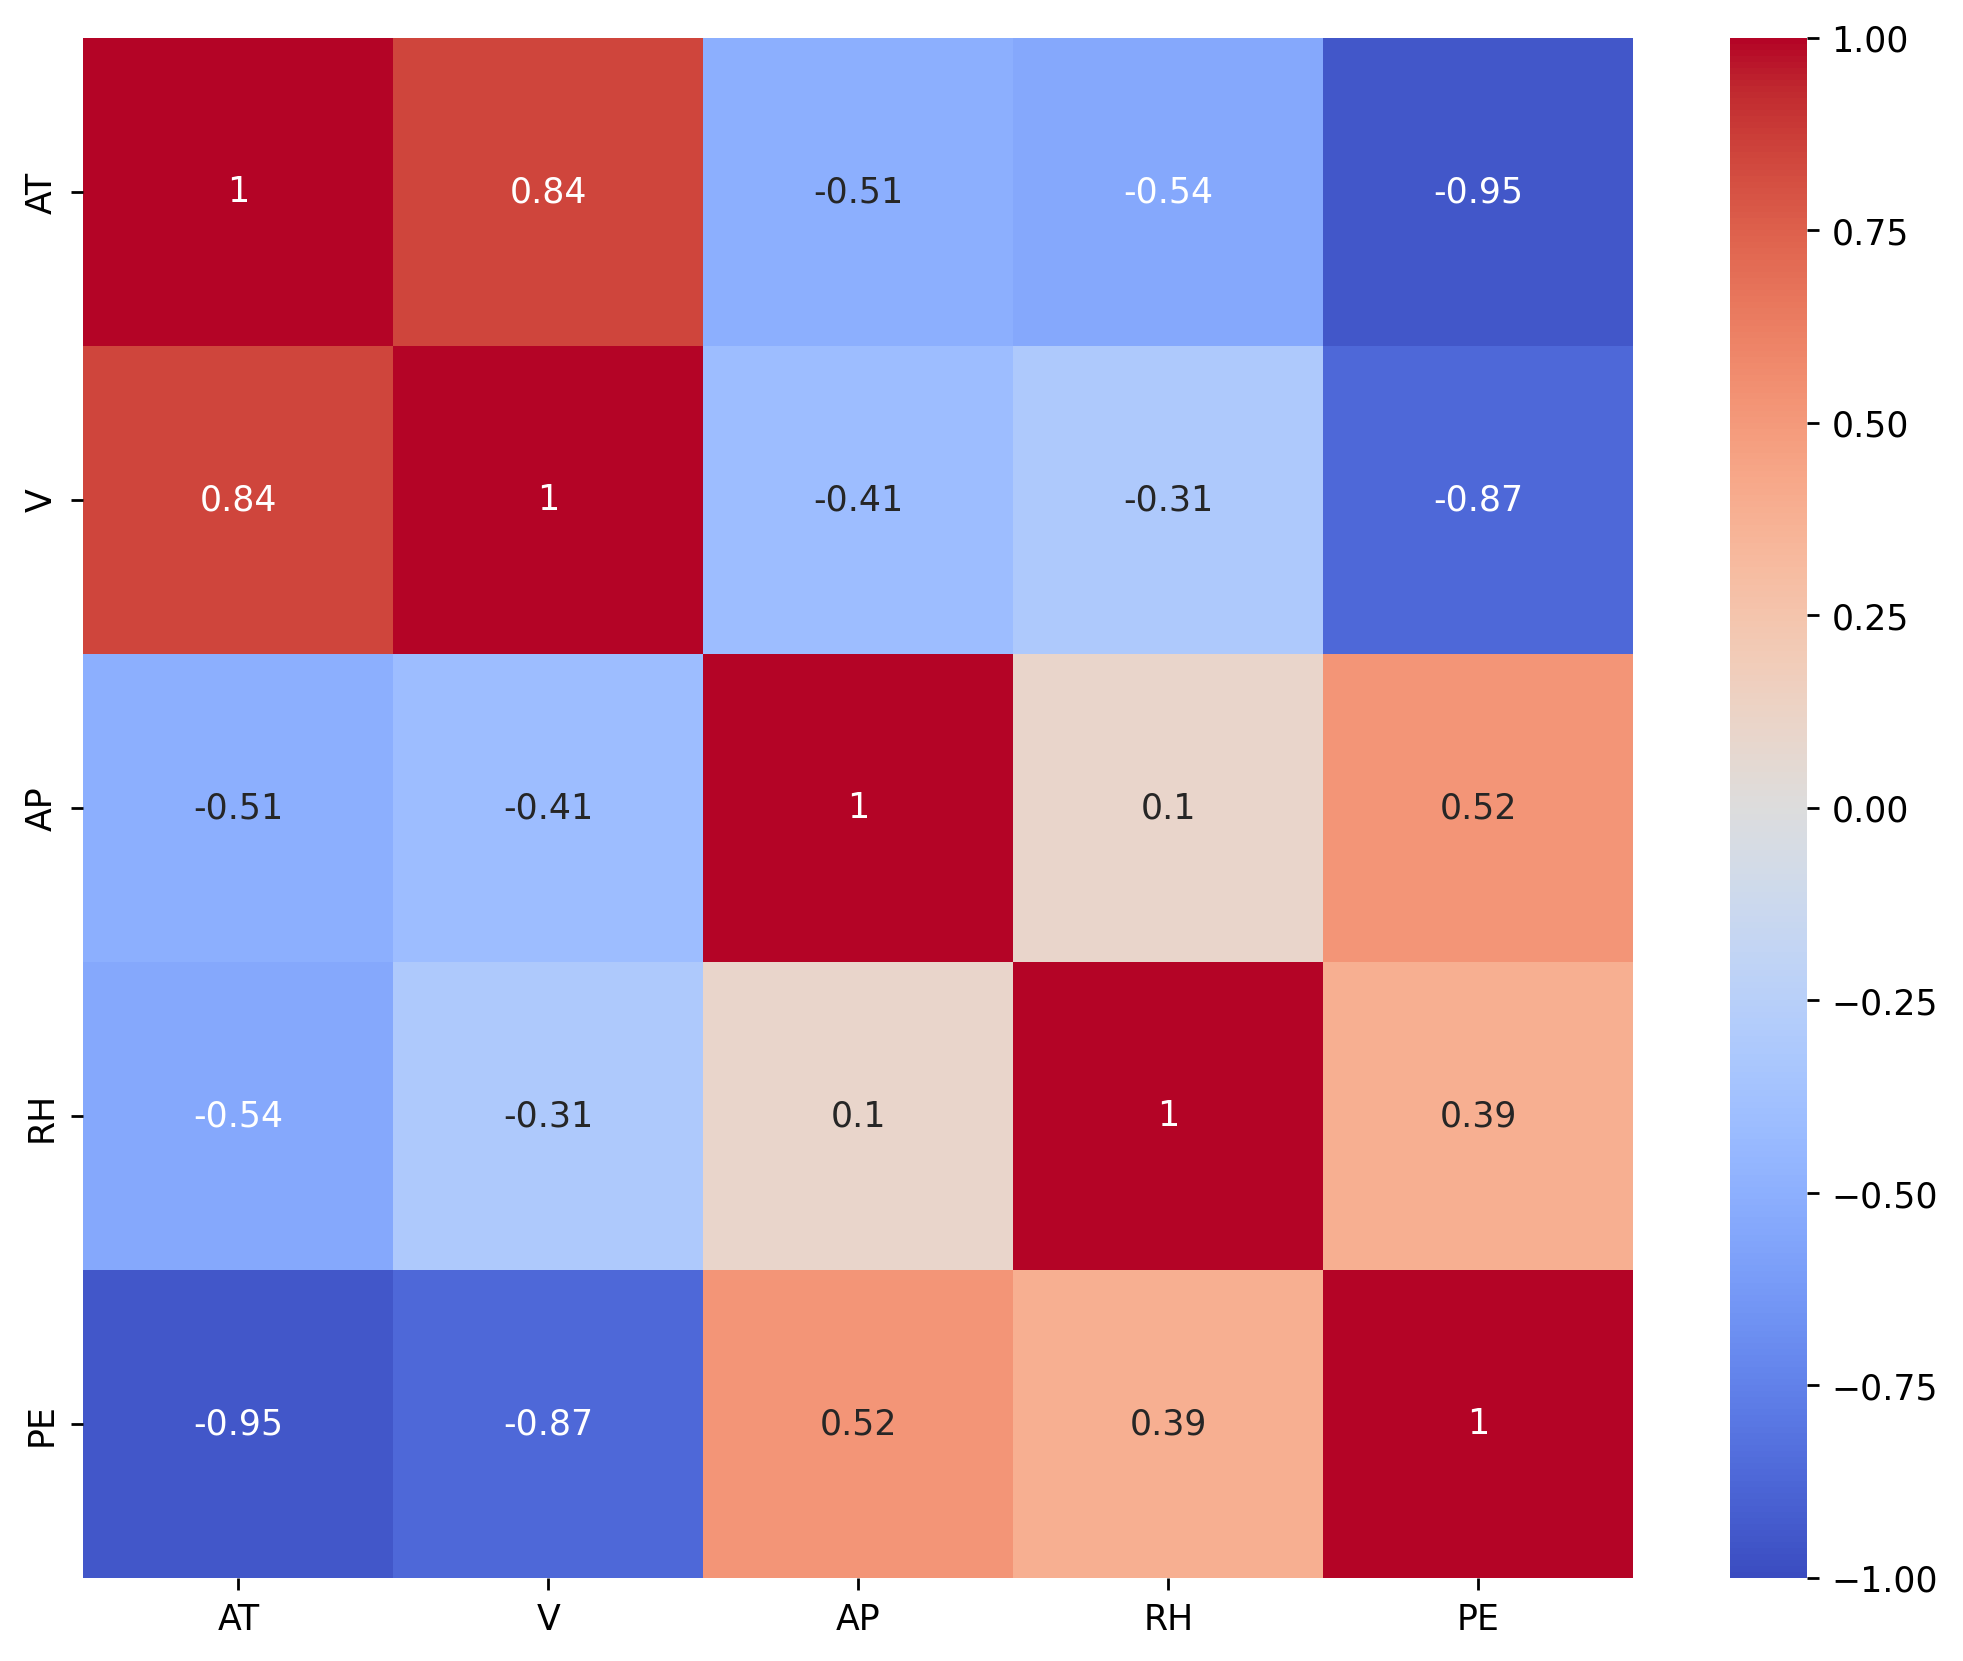

In [5]:
plt.figure(figsize=(10,8), dpi=250)
sns.heatmap(data=dataset.corr(), annot=True, vmin=-1, vmax=1, cmap='coolwarm' )

In [6]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

### Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Part 2 - Building the ANN

### Initializing the ANN

In [8]:
ann = tf.keras.models.Sequential()

### Adding the input layer and the first hidden layer

In [9]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

### Adding the second hidden layer

In [10]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

### Adding the output layer

In [11]:
ann.add(tf.keras.layers.Dense(units=1))

## Part 3 - Training the ANN

### Compiling the ANN

In [12]:
ann.compile(optimizer = 'adam', loss = 'mean_squared_error')

### Training the ANN model on the Training set

In [13]:
ann.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 987us/step - loss: 321.6672   
Epoch 2/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 940us/step - loss: 186.9659
Epoch 3/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 969us/step - loss: 138.1864
Epoch 4/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 925us/step - loss: 109.2573
Epoch 5/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 875us/step - loss: 92.0717 
Epoch 6/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - loss: 81.3043
Epoch 7/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - loss: 71.7435
Epoch 8/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - loss: 64.9887
Epoch 9/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step - loss: 61.0544
Epoch 10/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step - loss: 55.8303
Epoch 11/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - loss: 51.3550
Epoch 12/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 878us/step - loss: 48.4276
Epoch 13/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - loss: 45.2250
Epoch 14/100
240/240 ━━━━━━━━━━━━━━━━━━━━ 0s 868us/step - loss: 4

In [14]:
y_pred = ann.predict(X_test)
np.set_printoptions(precision=2)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
[[432.51 431.23]
 [463.58 460.01]
 [467.08 461.14]
 ...
 [474.33 473.26]
 [441.05 438.  ]
 [460.28 463.28]]


In [15]:
y_pred = ann.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
my_r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {my_r2:.2f}")

60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 762us/step
MAE: 4.11
MSE: 26.07
RMSE: 5.11
R2 Score: 0.91


In [16]:
single_input = np.array([[15.75, 52.34, 1015.44, 75.12]])

In [17]:
prediction = ann.predict(single_input)
print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[463.53]]


In [18]:
end_time = time.time()
total_time = end_time - start_time
print(total_time)

26.736905336380005
